<a href="https://colab.research.google.com/github/Saiakashaya/DATA_SCIENCE/blob/main/logistic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
!pip install kaggle

In [38]:
!kaggle datasets download mhdzahier/travel-insurance

Dataset URL: https://www.kaggle.com/datasets/mhdzahier/travel-insurance
License(s): ODbL-1.0
travel-insurance.zip: Skipping, found more recently modified local copy (use --force to force download)


In [39]:
ls-ltr /content

total 4932
-rw-r--r-- 1 root root 4570914 Nov  5  2019 'travel insurance.csv'
-rw-r--r-- 1 root root  473717 Nov  5  2019  travel-insurance.zip
drwxr-xr-x 1 root root    4096 Jun  4 13:32  sample_data/


In [40]:
!unzip travel-insurance.zip

Archive:  travel-insurance.zip
replace travel insurance.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [41]:
import pandas as pd
df=pd.read_csv("travel insurance.csv")
print("First 5 Rows")
df.head()

First 5 Rows


,Agency,Agency Type,Distribution Channel,Product Name,Claim,Duration,Destination,Net Sales,Commision (in value),Gender,Age
0,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,F,81
1,CBH,Travel Agency,Offline,Comprehensive Plan,No,186,MALAYSIA,-29.0,9.57,F,71
2,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,65,AUSTRALIA,-49.5,29.70,NaN,32
3,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,60,AUSTRALIA,-39.6,23.76,NaN,32
4,CWT,Travel Agency,Online,Rental Vehicle Excess Insurance,No,79,ITALY,-19.8,11.88,NaN,41


In [42]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/117v52a8a-vOJpZz9fHutjPNO1gm_QptihxLfKlrv0Og/edit#gid=0


In [43]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
Agency                      0
Agency Type                 0
Distribution Channel        0
Product Name                0
Claim                       0
Duration                    0
Destination                 0
Net Sales                   0
Commision (in value)        0
Gender                  45107
Age                         0
dtype: int64


In [44]:
df.drop_duplicates(inplace=True)

print("\nDataset Shape:", df.shape)


Dataset Shape: (55284, 11)


In [45]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
le = LabelEncoder()
df["Claim"] = le.fit_transform(df["Claim"])

In [46]:
x=df["Commision (in value)"]
y=df["Claim"]

In [47]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

In [48]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train.values.reshape(-1,1))
x_test=scaler.transform(x_test.values.reshape(-1,1))

In [50]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [52]:
from sklearn.metrics import(accuracy_score,confusion_matrix,classification_report)
accuracy= accuracy_score(y_test,y_pred)
print("Accuracy score:",accuracy)
print(round(accuracy*100,2),"%")
print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))
print("\nClassification Report")
print(classification_report(y_test,y_pred))

Accuracy score: 0.98317807723614
98.32 %

Confusion Matrix
[[10871     2]
 [  184     0]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     10873
           1       0.00      0.00      0.00       184

    accuracy                           0.98     11057
   macro avg       0.49      0.50      0.50     11057
weighted avg       0.97      0.98      0.98     11057



In [53]:
commision_in_value=(input("\nEnter Commision (in value): "))
user=pd.DataFrame([[commision_in_value]],columns=["Commision (in value)"])
user_scaled=scaler.transform(user.values.reshape(-1,1))
prediction=model.predict(user_scaled)
probability=model.predict_proba(user_scaled)
print("\nProbability")
print("Not Claim: ",round(probability[0][0]*100,2),"%")
print("Claim: ",round(probability[0][1]*100,2),"%")
if prediction[0]==1:
            print("\nRESULT : CLAIM")
else:
            print("\nRESULT : NOT CLAIM")


Enter Commision (in value): 995

Probability
Not Claim:  0.0 %
Claim:  100.0 %

RESULT : CLAIM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


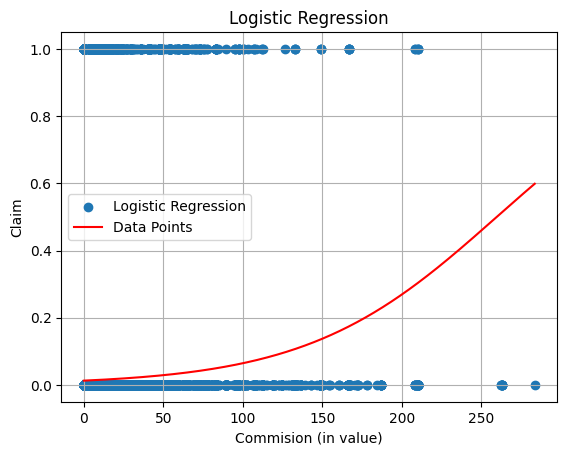

In [65]:
import numpy as np
import matplotlib.pyplot as plt
x_range=np.linspace(df["Commision (in value)"].min(),df["Commision (in value)"].max(),1000)
x_df=pd.DataFrame(x_range,columns=["Commision (in value)"])
x_range_scaled=scaler.transform(x_df)
y_range=model.predict_proba(x_range_scaled)[:,1]
plt.scatter(df["Commision (in value)"],df["Claim"])
plt.plot(x_range,y_range,color="red")
plt.xlabel("Commision (in value)")
plt.ylabel("Claim")
plt.title("Logistic Regression")
plt.grid(True)
plt.legend(["Logistic Regression","Data Points"])
plt.show()